# Pleiades Analysis using Gaia Data

This notebook identifies cluster members, the Seven Sisters, and constructs the color-magnitude diagram.

In [2]:
import os
import pandas as pd
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

# 读取数据
df = pd.read_excel("gaia.xlsx")

# 清洗数据
df = df.apply(pd.to_numeric, errors='coerce')
df = df.dropna()

# 聚类
X = df[["pm_RA", "pm_Dec", "Distance (pc)"]]
clustering = DBSCAN(eps=5, min_samples=5).fit(X)

df["cluster"] = clustering.labels_

## (f) Identifying Pleiades Members

Stars were classified using clustering based on proper motion and distance.

In [3]:
members = df[df["cluster"] == 0]
non_members = df[df["cluster"] == -1]

print("Members (5 examples):")
print(members["Number"].head(5).values)

print("Non-members (5 examples):")
print(non_members["Number"].head(5).values)

Members (5 examples):
[ 4.  5.  8.  9. 10.]
Non-members (5 examples):
[1. 2. 3. 6. 7.]


## (g) Identifying the Seven Sisters

The brightest stars in the cluster are selected.

In [4]:
seven_sisters = members.sort_values(by="Gp").head(7)

print("Seven Sisters (by Number):")
print(seven_sisters["Number"].values)

Seven Sisters (by Number):
[391. 369. 210. 222. 255. 413. 322.]


## (h) Color-Magnitude Diagram

The CMD is plotted using Bp − Rp and G magnitude.

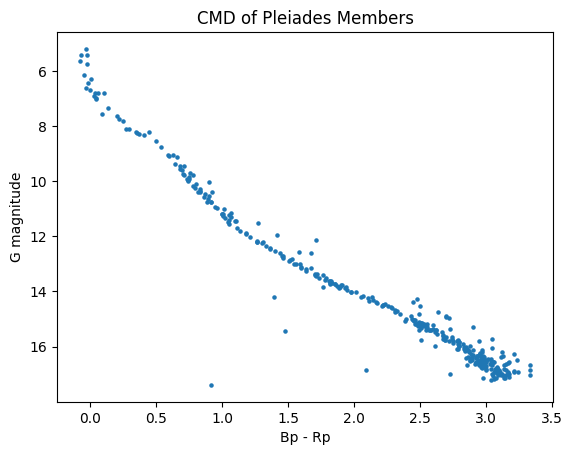

In [5]:
plt.scatter(members["Bp"] - members["Rp"], members["Gp"], s=5)
plt.gca().invert_yaxis()

plt.xlabel("Bp - Rp")
plt.ylabel("G magnitude")
plt.title("CMD of Pleiades Members")

plt.show()

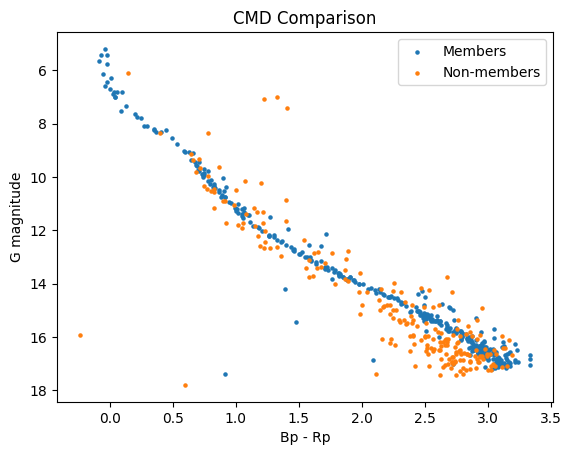

In [6]:
plt.scatter(members["Bp"] - members["Rp"], members["Gp"], s=5, label="Members")
plt.scatter(non_members["Bp"] - non_members["Rp"], non_members["Gp"], s=5, label="Non-members")

plt.gca().invert_yaxis()
plt.xlabel("Bp - Rp")
plt.ylabel("G magnitude")
plt.legend()
plt.title("CMD Comparison")

plt.show()

More massive stars appear in the upper-left region of the CMD, where stars are brighter and bluer.

The Pleiades members form a clear main sequence, indicating similar age and distance, while non-members are scattered.